In [173]:
import seaborn as sns
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import json

save_path = Path("diagrams/mrs_analysis")
save_path.mkdir(exist_ok=True)

In [174]:
allensbach_columns = [
        "Age",
        "Occupation Group",
        "Occupation",
        "Sex",
        "Optimism",
        "Pessimism",
        "Graduation",
        "Weekly Working Hours",
        "Resilience",
    ]

In [175]:
result_path = Path("../results/downstream_task")
less_bias_strengths = ["0.1"]
method_names = ["mrs_step", "random"]

In [176]:
feature_importance = []
dict_list = []
json_file = result_path / "gbs_allensbach" / "none" /  "0.1" / "fw-mrs-temperature-svm" / "classification_results" / "abs_feature_importance.json"
with open(json_file) as file:
    fw_mrs_result_file = np.array(json.load(file))
fw_mrs_result_file = [value / np.sum(value) for value in fw_mrs_result_file]

uniform_json_file = result_path / "gbs_allensbach" / "none" /  "0.1" / "uniform" / "classification_results" / "abs_feature_importance.json"
with open(uniform_json_file) as file:
    uniform_result_file = np.array(json.load(file))
    uniform_result_file = [value / np.sum(value) for value in uniform_result_file]

mrs_json_file = result_path / "gbs_allensbach" / "none" /  "0.1" / "mrs-forest" / "classification_results" / "abs_feature_importance.json"
with open(uniform_json_file) as file:
    mrs_result_file = np.array(json.load(file))
    mrs_result_file = [value / np.sum(value) for value in mrs_result_file]

df = pd.DataFrame([{"Method": "Uniform", "Feature Importance": uniform_result_file},
                    {"Method": "FW-MRS-SVM", "Feature Importance": fw_mrs_result_file},
                    {"Method": "MRS", "Feature Importance": mrs_result_file}])

In [177]:
df = df.explode("Feature Importance")
df[allensbach_columns] = df["Feature Importance"].tolist()
df = df.drop(columns=["Feature Importance"])
df = df.reset_index(drop=True)

In [178]:
df

,Method,Age,Occupation Group,Occupation,Sex,Optimism,Pessimism,Graduation,Weekly Working Hours,Resilience
0,Uniform,0.141532,0.081423,0.010973,0.061218,0.121371,0.117840,0.170758,0.140142,0.154744
1,Uniform,0.202933,0.051400,0.008892,0.063745,0.251093,0.095102,0.163503,0.056838,0.106494
2,Uniform,0.187544,0.058455,0.008146,0.066281,0.155474,0.169344,0.136329,0.099730,0.118697
3,Uniform,0.190891,0.059279,0.037575,0.069269,0.129458,0.177937,0.127964,0.046881,0.160745
4,Uniform,0.255493,0.066582,0.015896,0.049822,0.135619,0.101532,0.083896,0.084877,0.206283
...,...,...,...,...,...,...,...,...,...,...
97,MRS,0.291097,0.044542,0.043580,0.042821,0.166647,0.091887,0.091412,0.080097,0.147917
98,MRS,0.181320,0.084036,0.015967,0.060830,0.153187,0.143523,0.115539,0.105214,0.140384
99,MRS,0.149893,0.080558,0.008540,0.055319,0.204237,0.137385,0.154795,0.039783,0.169491
100,MRS,0.236171,0.052126,0.009296,0.039922,0.180075,0.097368,0.147805,0.092247,0.144989


In [179]:
df = pd.melt(df, id_vars="Method")

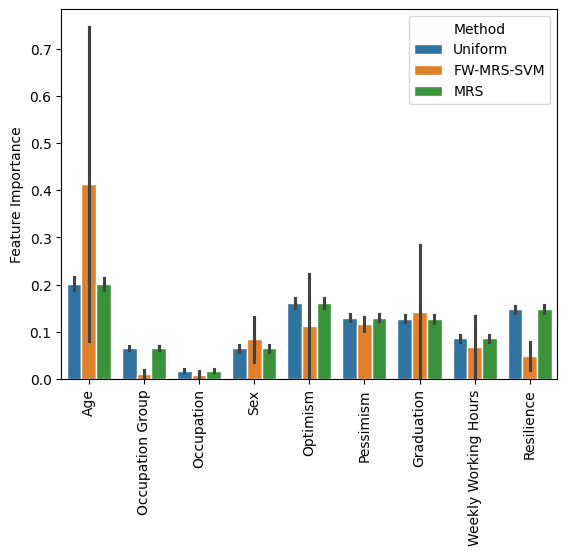

In [ ]:
ax = sns.barplot(data=df, x="variable", y="value", hue="Method", linewidth=1, edgecolor='w')
ax.set(xlabel="", ylabel='Feature Importance')
_ = plt.xticks(rotation=90)